# 01 — Pipeline audit & preprocessing diagnostics

This notebook loads the 120 JSON files (`{scheme}_{policy}_v{vehicle}.json`), runs the v15 preprocessing,
and produces a few diagnostic tables that should appear in **Appendix B.1**:

- raw turn counts
- truncation / parse-failure rates
- agreement and floor-hit rates
- size of the `D_persist` vs `D_negotiation` partition for each feature family
- one sanity-check linear fit on a single (scheme, policy) slice to confirm Yₜ behaves the way we expect.

All v15 constants (η = 1e-4, agreement multiplier 1.005, persist threshold 1e-2, round range [3, 12]) live in `negolin_v15.py`.

In [1]:
# Imports + paths
import os, sys, warnings
warnings.simplefilter('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make sure negolin_v15.py lives next to this notebook (or fix sys.path)
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))
import negolin_v15 as nv

DATA_DIR = 'merged_results'   # <-- set to your unzipped merged_results folder
OUT_DIR  = './out'
os.makedirs(OUT_DIR, exist_ok=True)
print(nv.feature_summary())

  family                                        description  tau  dim_phi
0      I                         (1, B_t, S_{t-1}, B_{t-1})    1        4
1     II                       (1, B_t, S^L_{t-1}, B_{t-1})    1        4
2    III   (1, B_t, S^L_{t-1}, B_{t-1}, S^L_{t-2}, B_{t-2})    2        6
3     IV  (1, B_t^+, B_t^-, S^L_{t-1}, B_{t-1}^+, B_{t-1...    1        6
4      V                               (1, dB_t, S^L_{t-1})    1        3
5     VI                      (1, dB_t, S^L_{t-1}, Y_{t-1})    2        4
6    VII  (1, B_t^+, B_t^-, dB_t^+, dB_t^-, S^L_{t-1}, Y...    2        7


## 1. Load every JSON

`load_run_files` returns one row per (scheme, policy, vehicle, run, round) with globally-unique `run_id`.

In [2]:
raw = nv.load_run_files(DATA_DIR)
print(f'rows = {len(raw):,}')
print(f'unique runs = {raw.run_id.nunique():,}  (expected 4·6·5·50 = 6000)')
raw.head()

rows = 50,401
unique runs = 6,000  (expected 4·6·5·50 = 6000)


,scheme,policy,vehicle_id,car_name,M,v,run_id,run_local,round,buyer_price_raw,seller_price_raw,buyer_template_id
0,A,PVD,1,2014 Mercedes-Benz S550,96000.0,19000.0,0,0,1,2087.30,28750.00,6
1,A,PVD,1,2014 Mercedes-Benz S550,96000.0,19000.0,0,0,2,28533.16,28533.16,4
2,A,PVD,1,2014 Mercedes-Benz S550,96000.0,19000.0,1,1,1,9286.86,27500.00,2
3,A,PVD,1,2014 Mercedes-Benz S550,96000.0,19000.0,1,1,2,9286.86,25500.00,5
4,A,PVD,1,2014 Mercedes-Benz S550,96000.0,19000.0,1,1,3,9286.86,24500.00,3


## 2. Preprocess

`preprocess_turns` applies the v15 rules:

1. Truncate Sₜ to [v, M].
2. Detect agreement (Sₜ ≤ 1.005·Bₜ) and floor-hit (Sₜ ≤ v).
3. **Drop rows strictly after the first such turn** (keep the terminal turn itself).
4. Compute B̃ₜ, S̃ₜ, S̃ᴸₜ (logit-clipped with η = 1e-4), Yₜ, and one/two-step lags.

In [3]:
marked, turns = nv.preprocess_turns(raw)
print(f'rows after dropping post-terminal turns: {len(turns):,} of {len(marked):,}')

diag = pd.DataFrame({
    'rate': [marked.parse_fail.mean(),
             marked.lower_truncated.mean(),
             marked.upper_truncated.mean(),
             marked.agreement_flag.mean(),
             marked.floor_flag.mean(),
             marked.terminal_flag.mean()]
}, index=['parse_fail','S<v (lower trunc)','S>M (upper trunc)','agreement','floor hit','terminal (any)'])
diag

rows after dropping post-terminal turns: 45,779 of 50,401


,rate
parse_fail,0.000079
S<v (lower trunc),0.001052
S>M (upper trunc),0.000000
agreement,0.076903
floor hit,0.107319
terminal (any),0.179242


Per-(scheme, policy) version of the same — useful for the appendix table.

In [4]:
by_grp = (marked.groupby(['scheme','policy'])
         .agg(parse_fail=('parse_fail','mean'),
              lower_trunc=('lower_truncated','mean'),
              upper_trunc=('upper_truncated','mean'),
              agreement=('agreement_flag','mean'),
              floor=('floor_flag','mean'),
              n_turns=('round','size'))
         .round(4))
by_grp.to_csv(os.path.join(OUT_DIR, 'preproc_diagnostics.csv'))
by_grp

parse_fail  lower_trunc  upper_trunc  agreement   floor  \
scheme policy                                                            
A      FRB         0.0000       0.0010          0.0     0.0725  0.2242   
       IC          0.0000       0.0005          0.0     0.0760  0.1416   
       MEVJ        0.0000       0.0005          0.0     0.0947  0.0784   
       OADS        0.0000       0.0005          0.0     0.0724  0.2148   
       PVD         0.0005       0.0005          0.0     0.0803  0.0372   
       RFK         0.0000       0.0005          0.0     0.0609  0.0664   
B      FRB         0.0000       0.0050          0.0     0.0685  0.2484   
       IC          0.0004       0.0013          0.0     0.0631  0.2833   
       MEVJ        0.0000       0.0013          0.0     0.0819  0.1210   
       OADS        0.0000       0.0009          0.0     0.0705  0.2371   
       PVD         0.0000       0.0000          0.0     0.0910  0.0726   
       RFK         0.0004       0.0026          0.0     0.0601  0.2717   
C      FRB         0.0000       0.0024          0.0     0.0370  0.0845   
       IC          0.0000       0.0012          0.0     0.0369  0.0705   
       MEVJ        0.0000       0.0000          0.0     0.0369  0.0101   
       OADS        0.0000       0.0004          0.0     0.0380  0.0384   
       PVD         0.0000       0.0000          0.0     0.0389  0.0041   
       RFK         0.0000       0.0013          0.0     0.0438  0.0303   
D      FRB         0.0000       0.0017          0.0     0.1398  0.0920   
       IC          0.0000       0.0012          0.0     0.1381  0.0758   
       MEVJ        0.0000       0.0000          0.0     0.1368  0.0165   
       OADS        0.0000       0.0011          0.0     0.1378  0.0543   
       PVD         0.0000       0.0000          0.0     0.1328  0.0100   
       RFK         0.0006       0.0006          0.0     0.1411  0.0802   

               n_turns  
scheme policy           
A      FRB        1931  
       IC         1935  
       MEVJ       1901  
       OADS       1960  
       PVD        2068  
       RFK        2183  
B      FRB        2218  
       IC         2252  
       MEVJ       2223  
       OADS       2185  
       PVD        2177  
       RFK        2311  
C      FRB        2462  
       IC         2441  
       MEVJ       2468  
       OADS       2449  
       PVD        2418  
       RFK        2375  
D      FRB        1717  
       IC         1716  
       MEVJ       1754  
       OADS       1749  
       PVD        1800  
       RFK        1708

## 3. Round-range and feature-availability counts

How many rows survive once we restrict to t ∈ [3, 12] and require lags up to τ = 2 (feature **VII**)?
How big is `D_negotiation` (|Yₜ| > 1e-2) vs `D_persist`?

In [5]:
rows = []
for (sch, pol), g in turns.groupby(['scheme','policy']):
    n_all = len(g)
    n_in_range = int(g['round'].between(nv.MODEL_ROUND_MIN, nv.MODEL_ROUND_MAX).sum())
    for fam in ['I','II','III','IV','V','VI','VII']:
        meta, X, y, _ = nv.build_design_matrix(g, fam)
        (_, _, _), (mn, _, yn) = nv.partition_persist(meta, X, y)
        rows.append({'scheme': sch, 'policy': pol, 'family': fam,
                     'n_in_round_range': n_in_range,
                     'n_design_rows': len(meta),
                     'n_persist': len(meta) - len(mn),
                     'n_negotiation': len(mn),
                     'frac_neg': len(mn)/max(len(meta),1)})
feat_avail = pd.DataFrame(rows)
feat_avail.to_csv(os.path.join(OUT_DIR, 'feature_availability.csv'), index=False)
feat_avail.head(14)

,scheme,policy,family,n_in_round_range,n_design_rows,n_persist,n_negotiation,frac_neg
0,A,FRB,I,1054,1054,137,917,0.870019
1,A,FRB,II,1054,1054,137,917,0.870019
2,A,FRB,III,1054,1054,137,917,0.870019
3,A,FRB,IV,1054,1054,137,917,0.870019
4,A,FRB,V,1054,1054,137,917,0.870019
5,A,FRB,VI,1054,1054,137,917,0.870019
6,A,FRB,VII,1054,1054,137,917,0.870019
7,A,IC,I,1198,1198,313,885,0.738731
8,A,IC,II,1198,1198,313,885,0.738731
9,A,IC,III,1198,1198,313,885,0.738731


Average **negotiation fraction** by (scheme, policy) — feature VII (the most data-hungry).

In [6]:
piv = (feat_avail.query("family == 'VII'")
       .pivot(index='policy', columns='scheme', values='frac_neg')
       .round(3))
piv

scheme,A,B,C,D
policy,,,,
FRB,0.870,0.936,0.813,0.838
IC,0.739,0.891,0.536,0.786
MEVJ,0.802,0.924,0.590,0.801
OADS,0.854,0.942,0.671,0.819
PVD,0.690,0.893,0.494,0.800
RFK,0.558,0.916,0.509,0.829


**Quick read.** Buyer scheme **B** (slow fractional concession) keeps the seller actively negotiating ~90% of the time across all policies, while **C** (random walk with retreats) often pushes the seller into long persistence stretches — for IC, RFK, and PVD, fewer than 55% of qualifying turns make it into D_negotiation. This is exactly the situation the paper warns about: how D_persist is treated at evaluation time matters most under buyer C.

## 4. Distribution of Yₜ

Yₜ should be mostly negative (sellers concede), with a heavy point-mass near zero (persistence).

mean Y = -0.480, std = 0.636, frac |Y|<=1e-2 = 0.224


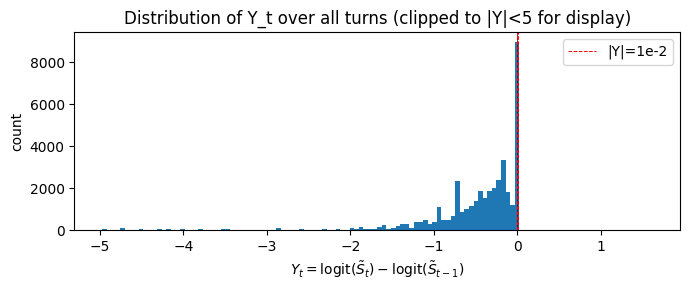

In [7]:
y_all = turns['Y'].dropna().to_numpy()
y_all = y_all[(np.abs(y_all) < 5)]   # drop a few extreme tails for plotting
print(f'mean Y = {y_all.mean():.3f}, std = {y_all.std():.3f}, frac |Y|<=1e-2 = {(np.abs(y_all) <= 1e-2).mean():.3f}')

fig, ax = plt.subplots(figsize=(7,3))
ax.hist(y_all, bins=120)
ax.axvline(0, color='k', lw=0.5)
ax.axvline( 1e-2, color='red', ls='--', lw=0.7, label='|Y|=1e-2')
ax.axvline(-1e-2, color='red', ls='--', lw=0.7)
ax.set_xlabel(r'$Y_t = \mathrm{logit}(\tilde S_t) - \mathrm{logit}(\tilde S_{t-1})$')
ax.set_ylabel('count')
ax.set_title('Distribution of Y_t over all turns (clipped to |Y|<5 for display)')
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'fig_Y_distribution.png'), dpi=130)
plt.show()

## 5. Sanity-check fit on (A, PVD)

Verify the pipeline gives sensible numbers on one slice before launching the sweep.

In [8]:
sch, pol = 'A', 'PVD'
sub = turns.query('scheme == @sch and policy == @pol')

out = []
for fam in ['Base','I','II','III','IV','V','VI','VII']:
    meta, X, y, cols = nv.build_design_matrix(sub, fam)
    (_, _, _), (m_n, X_n, y_n) = nv.partition_persist(meta, X, y)
    if fam == 'Base':
        pred, _ = nv.grouped_cv_predict(m_n, X_n, y_n, 'Base')
        m = nv.cv_metrics(pred); m['family']='Base'; m['model']='Base'
    else:
        for mdl in ['OLS','Ridge']:
            pred, _ = nv.grouped_cv_predict(m_n, X_n, y_n, mdl)
            mm = nv.cv_metrics(pred); mm['family']=fam; mm['model']=mdl
            out.append(mm)
        continue
    out.append(m)
audit = pd.DataFrame(out)[['family','model','n','mae','mae_se','mae_dollar','mape','mape_dollar','rmse']]
audit.round(4)

,family,model,n,mae,mae_se,mae_dollar,mape,mape_dollar,rmse
0,Base,Base,1041,0.6340,0.0531,544.6757,1.8598,0.6956,1.2740
1,I,OLS,1041,0.3967,0.0266,602.7409,1.6462,0.6221,0.7918
2,I,Ridge,1041,0.3959,0.0265,601.2382,1.6418,0.6229,0.7918
3,II,OLS,1041,0.3911,0.0256,561.0955,1.5190,0.6214,0.7819
4,II,Ridge,1041,0.3905,0.0255,560.7025,1.5185,0.6220,0.7819
5,III,OLS,1040,0.3835,0.0266,520.4894,1.3766,0.5983,0.7740
6,III,Ridge,1040,0.3820,0.0262,529.5152,1.4177,0.6044,0.7747
7,IV,OLS,1041,0.3923,0.0250,568.5611,1.4954,0.6185,0.7807
8,IV,Ridge,1041,0.3915,0.0250,567.8330,1.4965,0.6189,0.7806
9,V,OLS,1041,0.3899,0.0255,562.5097,1.5721,0.6316,0.7856


### Things to notice in the audit

- The **Base** (persistence) model has a *much* worse Yₜ-scale MAE than even the simplest linear specification, which is the whole point of including it as a null benchmark.
- However, on the **dollar scale**, Base is competitive or better than OLS/Ridge for several feature families. This is the **sigmoid-inversion artifact**: a model fit on Yₜ converts back to S̃ₜ via σ(·), and small Yₜ-scale errors near the flat regions of the sigmoid get *expanded* on the S̃ scale. Worth flagging in §B.2 — the dollar-scale metric is more lenient toward the persistence baseline than the Yₜ-scale metric, and the comparison should not be read as 'Base ties OLS'.
- Adding **Yₜ₋₁** (families VI, VII) noticeably improves linear MAE — concession *velocity* carries information beyond the static state.